<a href="https://colab.research.google.com/github/ShivaniYadav354/AIML-projects-/blob/main/Resume_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Resume.csv")
df

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."
...,...,...
957,Testing,Computer Skills: â¢ Proficient in MS office (...
958,Testing,â Willingness to accept the challenges. â ...
959,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...


In [4]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [5]:
df.sample(2)

,Category,Resume
489,Electrical Engineering,Education Details \r\nJuly 2016 to May 2019 BE...
167,Web Designing,"Technical Skills Web Technologies: Angular JS,..."


In [6]:
df["Category"].iloc[0]

'Data Science'

In [7]:
df["Category"].value_counts()

,count
Category,
Java Developer,84
Testing,70
DevOps Engineer,55
Python Developer,48
Web Designing,45
HR,44
Hadoop,42
Sales,40
Data Science,40


In [8]:
df.shape

(962, 2)

In [9]:
df["Category"].nunique

<bound method IndexOpsMixin.nunique of 0      Data Science
1      Data Science
2      Data Science
3      Data Science
4      Data Science
           ...     
957         Testing
958         Testing
959         Testing
960         Testing
961         Testing
Name: Category, Length: 962, dtype: object>

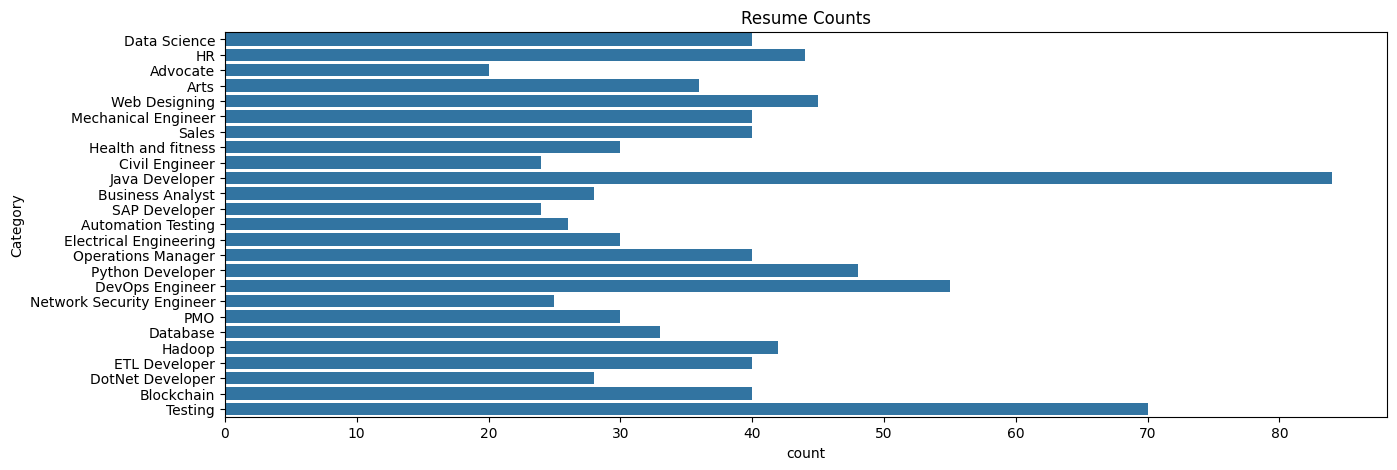

In [10]:
plt.figure(figsize =(15,5))
sns.countplot(df["Category"])
plt.title("Resume Counts")
plt.show()

In [11]:
#oversampling to handle the class imbalanace
max_size =df["Category"].value_counts().max()
balanced_df= df.groupby("Category").apply(lambda x:x.sample(max_size, replace=True)).reset_index(drop=True)
df= balanced_df.sample(frac=1).reset_index(drop=True)

/tmp/ipykernel_1238/1988454501.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df= df.groupby("Category").apply(lambda x:x.sample(max_size, replace=True)).reset_index(drop=True)


In [12]:
df

,Category,Resume
0,Automation Testing,"Technical Skills Summary I have completed ""COR..."
1,Electrical Engineering,Skills: 1) MC Office 2) AutoCAD 2016 3) Introd...
2,Hadoop,Education Details \r\n\r\nHadoop Developer \r\...
3,DotNet Developer,"Technical Skills CATEGORY SKILLS Language C, C..."
4,SAP Developer,Education Details \r\nJanuary 2016 Bachelor Of...
...,...,...
2095,HR,Education Details \r\n BBA lovely profession...
2096,Sales,Education Details \r\n Bachelor's \r\n Bache...
2097,DevOps Engineer,Skills VISA B1-VISA (USA) Onsite Visits to Swe...
2098,SAP Developer,Competencies: SAP Business Intelligence Versio...


In [13]:
# text processing : cleaing data{remove all (url , hastags , mentions , special characters, punctuation)}
import re

def cleanResume(txt):
    cleanText = re.sub('http\S+\s', ' ', txt)
    cleanText = re.sub('RT|cc', ' ', cleanText)
    cleanText = re.sub('#\S+\s', ' ', cleanText)
    cleanText = re.sub('@\S+', '  ', cleanText)
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)
    cleanText = re.sub('\s+', ' ', cleanText)
    return cleanText

<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\]'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\]'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1238/3407218404.py:5: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('http\S+\s', ' ', txt)
/tmp/ipykernel_1238/3407218404.py:7: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('#\S+\s', ' ', cleanText)
/tmp/ipykernel_1238/3407218404.py:8: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('@\S+', '  ', cleanText)
/tmp/ipykernel_1238/3407218404.py:9: SyntaxWarning: invalid escape sequence '\]'
  cleanText = re.sub('[%s]' % re.esca

In [14]:
cleanResume("hii:)#@%^ i am shivani yadav!!")

'hii i am shivani yadav '

In [15]:
df["Resume"]= df["Resume"].apply(lambda x:cleanResume(x))
df["Resume"][0]

'Technical Skills Summary I have completed CORPORATE TRAINING in Manual and Automation Testing at Source Code Technology Pune Manual and Automation Testing SELENIUM IDE TestNG SELENIUM Grid JENKINS Apache POI Good knowledge in SDLC Excellent understanding of White Box Testing and Black Box Testing Good knowledge in Functional Testing Integration Testing and System Testing Good Exposure in writing Functional and Integration Scenarios Good understanding of writing of test cases including test case design technique Good understanding Build and release Good knowledge on Ad hoc and smoke testing Excellent understanding of usability reliability and exploratory testing Excellent knowledge of Globalization and Compatibility Testing Excellent Understand of STLC Good knowledge of regression and retesting Excellent knowledge on Defect tracking and Defect Life Cycle Good Knowledge on Test plan and Traceability Matrix Internship Project Project Name Resume Extractor Duration 6 months Role Manual An

In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [17]:
le.fit(df["Category"])
df["Category"] = le.transform(df["Category"])
df["Category"].unique()

array([ 2, 11, 13,  9, 21,  4,  5, 17,  7, 19, 23, 18, 12,  8, 24,  6, 20,
       16, 10,  1, 22,  0,  3, 15, 14])

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf.fit(df["Resume"])

required_text = tfidf.transform(df["Resume"])

In [19]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    required_text,
    df["Category"],
    test_size=0.2
)

In [20]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score

In [21]:
svc_model = OneVsRestClassifier(SVC())
svc_model.fit(x_train, y_train)
y_pred = svc_model.predict(x_test)

In [22]:
accuracy_score(y_test, y_pred)

1.0

In [23]:
def pred(Resume_input):
    # preprocessing
    cleaned_text = cleanResume(Resume_input)

    # convert text into numeric value
    numeric_text = tfidf.transform([cleaned_text])

    # prediction
    #predict_category = svc_model.predict(numeric_text)

    # inverse numeric to text
    predicted_category_name = le.inverse_transform(svc_model.predict(numeric_text))
    return predicted_category_name[0]

In [24]:
myresume = myresume = """I am a data scientist specializing in machine
learning, deep learning, and computer vision. With
a strong background in mathematics, statistics,
and programming, I am passionate about
uncovering hidden patterns and insights in data.
I have extensive experience in developing
predictive models, implementing deep learning
algorithms, and designing computer vision
systems. My technical skills include proficiency in
Python, Sklearn, TensorFlow, and PyTorch.
What sets me apart is my ability to effectively
communicate complex concepts to diverse
audiences. I excel in translating technical insights
into actionable recommendations that drive
informed decision-making.
If you're looking for a dedicated and versatile data
scientist to collaborate on impactful projects, I am
eager to contribute my expertise. Let's harness the
power of data together to unlock new possibilities
and shape a better future.
Contact & Sources
Email: 611noorsaeed@gmail.com
Phone: 03442826192
Github: https://github.com/611noorsaeed
Linkdin: https://www.linkedin.com/in/noor-saeed654a23263/
Blogs: https://medium.com/@611noorsaeed
Youtube: Artificial Intelligence
ABOUT ME
WORK EXPERIENCE
SKILLES
NOOR SAEED
LANGUAGES
English
Urdu
Hindi
I am a versatile data scientist with expertise in a wide
range of projects, including machine learning,
recommendation systems, deep learning, and computer
vision. Throughout my career, I have successfully
developed and deployed various machine learning models
to solve complex problems and drive data-driven
decision-making
Machine Learnine
Deep Learning
Computer Vision
Recommendation Systems
Data Visualization
Programming Languages (Python, SQL)
Data Preprocessing and Feature Engineering
Model Evaluation and Deployment
Statistical Analysis
Communication and Collaboration
"""

In [25]:
pred(myresume)

'Data Science'

In [26]:
myresume = """
Jane Smith is a certified personal trainer with over 5 years of experience in helping individuals achieve their fitness goals. Specializing in weight loss, strength training, and sports conditioning, Jane has developed personalized workout routines for clients of all ages and fitness levels. She has extensive knowledge in nutrition and exercise science, and uses this to create holistic health and fitness programs that are tailored to individual needs.

Jane holds a degree in Exercise Science and is a certified trainer through the National Academy of Sports Medicine (NASM). She has worked with athletes, seniors, and individuals with chronic health conditions, helping them improve their physical well-being and overall quality of life.

Her expertise includes:
- Weight Loss and Body Composition
- Strength Training and Resistance Exercises
- Cardio Conditioning
- Nutrition Coaching and Meal Planning
- Injury Prevention and Rehabilitation
- Functional Movement and Flexibility Training
- Group Fitness Classes

Certifications:
- Certified Personal Trainer, NASM
- CPR and First Aid Certified
- Yoga Instructor (200-Hour Certification)

Education:
BSc in Exercise Science, ABC University, 2014-2018

Work Experience:
- Personal Trainer at XYZ Fitness Gym (2018-Present)
- Fitness Coach at Wellness Center (2016-2018)

Languages:
- English (Fluent)
- Spanish (Conversational)
"""

In [27]:
print(pred(myresume))

Health and fitness
